In [102]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline

try:
    %load_ext keras
except:
    !pip3 install keras

The keras module is not an IPython extension.


Input images - we will crete images (instaed of actual pictures) to make our life simplier. Gray scale image is just 2D array of pixels. We will create numpy array (8x8) of bits (0=> white , 1 => black pixel) with white background and random rectangle int it that has black background.

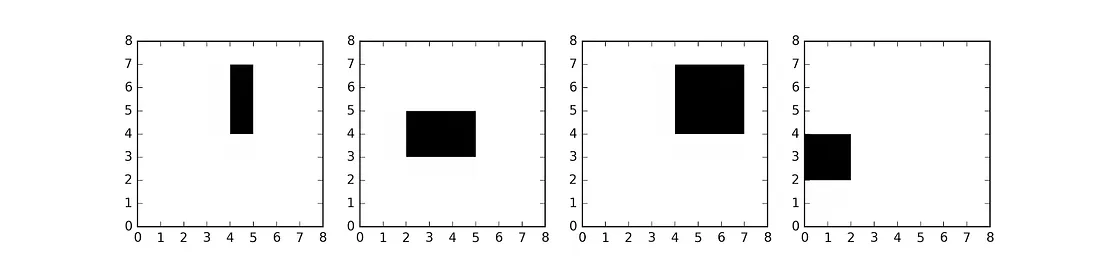


In [110]:
from operator import attrgetter

num_imgs = 50000

img_size = 8
min_rect_size = 1
max_rect_size = 4
num_objects = 1 #  lets start with only onetwo rectangle in image and later change to more

bboxes = np.zeros((num_imgs, num_objects, 4)) # creates 50000 3x4 gray scale images
imgs = np.zeros((num_imgs, img_size, img_size)) # creates 50000 8x8 gray scale images 

#create random rectangle ordered by lower left corner (x,y) 
random_rect = np.zeros((num_objects,4),dtype=int)


# add num_objects random rectangles with black pixels in the 8x8 white pixel image
for i_img in range(num_imgs):
    for i_object in range(num_objects): # create rectangles sorted on (x,y) - so machine learning also learns to output rectangles in sorted order of (x,y)
        # add rectangle dark color, with (x,y) as lower left coordinate and width is along x-axis and height is along y-axis
        width, height = np.random.randint(min_rect_size, max_rect_size, size=2) # return 2 random integers from range [1,4)
        x = np.random.randint(0, img_size - width) # return x = random  integer from range (0, 8-width)
        y = np.random.randint(0, img_size - height) # return y = random integer from range (0, 8-width)
        random_rect[i_object] = [x, y, width, height]
        #TODO - have to remove duplicate entries which are rectangles with same (x,y)
    # print(f'random_rect={random_rect}')
    random_rect = sorted(random_rect, key=lambda x:(x[0], x[1])) # sort [(x,y,width,height)]  first by x and then by y
    # print(f'sorted random_rect={random_rect}')

    for iter, rr in enumerate(random_rect): 
        x, y, width, height = rr[:4]
        imgs[i_img, x:x+width, y:y+height] = 1.0 # for current 8x8 image set cells (x,y) where from x->x+width and y->y_height to 1 (ie., rectange of black  pixels  )
        bboxes[i_img, iter] = [x, y, width, height]

print(f'imgs.shape={imgs.shape}, bboxes.shape={bboxes.shape}')



imgs.shape=(50000, 8, 8), bboxes.shape=(50000, 1, 4)


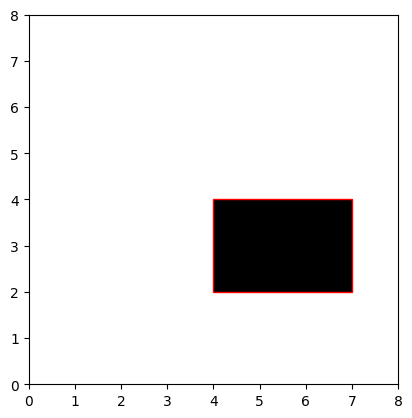

In [111]:
# plot one of the images
i = np.random.randint(0,num_imgs, size=1)[0] # return 1 random integer from range [0,num_imgs)
# numpy .T transposes the array .. not sure why 8x8 array needs to be transposed though
plt.imshow(imgs[i].T, cmap='Greys', interpolation='none', origin='lower', extent=[0, img_size, 0, img_size]) # plot the 8x8 white background
for bbox in bboxes[i]: # plot rectangles associated with current 8x8 image
    plt.gca().add_patch(matplotlib.patches.Rectangle((bbox[0], bbox[1]), bbox[2], bbox[3], ec='r', fc='none'))

We will create a simple feed forward NN with one hidden layer, no convolutions. Input layer takes flattened image 8x8 = 64 value array) and predicts the parameters of bounding box (ie., x,y which is lower left corner and width w and height h). During training, we simply do a regression of the predicted to the expected bounding boxes via mean squared error (MSE).adadelta optimizer, which is basically stochastic gradient descent with an adaptive learning rate is used here (it is good for experimentation since you don't need to spend much time on hyperparameter optimization).

In [ ]:
# usual CNN
# numpy resize changes shape of array while data remains same. resize(50000, -1) gives wil be now 50000 array each containing of  64 size array
# Looks author is using z-score here. z = (x - μ) / σ, where x is the data point, μ is the population mean, and σ is the population standard deviation
# A z-score of 0 means the data point is exactly at the mean, a positive z-score means the data point is above the mean, and a negative z-score means the data point is below the mean
# once Z-score is done, all the features wil have a mean of zero and standard deviation of one, and thus, the same scale

X = (imgs.reshape(num_imgs, img_size,img_size,1) - np.mean(imgs)) / np.std(imgs) # flatten image array (same as 'flipping'referred throughout the article) and also normalize dataset
print(f'shape of X = {X.shape}')
def PlotOneRectangle():
    # plot one of the images - start
    i = np.random.randint(0,num_imgs, size=1)[0] # return 1 random integer from range [0,num_imgs)
    # numpy .T transposes the array .. not sure why 8x8 array needs to be transposed though
    plt.imshow(imgs[i].T, cmap='Greys', interpolation='none', origin='lower', extent=[0, img_size, 0, img_size]) # plot the 8x8 white background
    for bbox in bboxes[i]: # plot bounding box rectangles associated with current 8x8 image
        plt.gca().add_patch(matplotlib.patches.Rectangle((bbox[0], bbox[1]), bbox[2], bbox[3], ec='r', fc='none'))
    # plot one of the images - end
# PlotOneRectangle()
print(f'X.shape={X.shape}, np.mean(X)={np.mean(X)}, np.std(X)={np.std(X)}') # print values
y = bboxes.reshape(num_imgs, -1) / img_size # reshape the training y values also to be 50000 1D array
print(f'y.shape={y.shape}')
i = int(0.8 * num_imgs) # 80% of dataset is for training 20% for testing
train_X = X[:i] # first i elements (0,i] of X
test_X = X[i:] # i to the end elements of X (i,length_of_array_X]
train_y = y[:i] # first i elements (0,i] of Y
test_y = y[i:] # i to the end elements of Y (i,length_of_array_Y]
test_imgs = imgs[i:] # (i,length_of_imgs] elements of imgs
test_bboxes = bboxes[i:] # (i,length_of_imgs] elements of bounding boxes

print('X.shape[-1]=',X.shape[-1])
print('y.shape[-1]=', y.shape[-1])
from keras.models import Sequential
from keras.layers import Conv2D, Flatten, MaxPooling2D, Dense, Dropout
from keras.optimizers import SGD


model = Sequential()
# add convolution layer - 64 neurons =>  64 kernel/filters each of size of kernel/filter = 3x3 which are all learnt after training / padding="same" means output image has same size as input image /
model.add(Conv2D(64, (3,3), padding="same", activation="relu", input_shape=(8,8,1)))
# add maxpool layer - downscale images
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(128, (3,3), padding="same", activation="relu"))
model.add(MaxPooling2D(pool_size=(2,2)))
# in hidden layers we increase number of filters (64 -> 128 -> 256) so each new layer learns more features
model.add(Conv2D(256, (3,3), padding="same", activation="relu"))
model.add(MaxPooling2D(pool_size=(2,2)))
#vectorize the overall output - changes to 1D vector of numbers
model.add(Flatten())
#add Dense layer
model.add(Dense(256, activation="relu"))
# 10 neurons since we have 10 output classes - multiclass classification => use softmax. binary classificaiton => use sigmoid
model.add(Dense(num_objects*4, activation="softmax"))


model.compile(optimizer="adam", loss='sparse_categorical_crossentropy', metrics=['sparse_categorical_accuracy'])
model.summary()

model.fit(train_X, flipped_train_y, epochs=num_epochs, validation_data=(test_X, test_y), verbose=2)

shape of X = (50000, 8, 8, 1)
X.shape=(50000, 8, 8, 1), np.mean(X)=1.0720313525780512e-17, np.std(X)=1.0000000000000004
y.shape=(50000, 4)
X.shape[-1]= 1
y.shape[-1]= 4


C:\Users\hramm\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 64)       │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 2, 2, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 1, 1, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 436,484 (1.67 MB)

 Trainable params: 436,484 (1.67 MB)

 Non-trainable params: 0 (0.00 B)

In [121]:
# numpy resize changes shape of array while data remains same. resize(50000, -1) gives wil be now 50000 array each containing of  64 size array
# Looks author is using z-score here. z = (x - μ) / σ, where x is the data point, μ is the population mean, and σ is the population standard deviation
# A z-score of 0 means the data point is exactly at the mean, a positive z-score means the data point is above the mean, and a negative z-score means the data point is below the mean
# once Z-score is done, all the features wil have a mean of zero and standard deviation of one, and thus, the same scale

X = (imgs.reshape(num_imgs, -1) - np.mean(imgs)) / np.std(imgs) # flatten image array (same as 'flipping'referred throughout the article) and also normalize dataset
X.shape
def PlotOneRectangle():
    # plot one of the images - start
    i = np.random.randint(0,num_imgs, size=1)[0] # return 1 random integer from range [0,num_imgs)
    # numpy .T transposes the array .. not sure why 8x8 array needs to be transposed though
    plt.imshow(imgs[i].T, cmap='Greys', interpolation='none', origin='lower', extent=[0, img_size, 0, img_size]) # plot the 8x8 white background
    for bbox in bboxes[i]: # plot bounding box rectangles associated with current 8x8 image
        plt.gca().add_patch(matplotlib.patches.Rectangle((bbox[0], bbox[1]), bbox[2], bbox[3], ec='r', fc='none'))
    # plot one of the images - end
# PlotOneRectangle()
print(f'X.shape={X.shape}, np.mean(X)={np.mean(X)}, np.std(X)={np.std(X)}') # print values
y = bboxes.reshape(num_imgs, -1) / img_size # reshape the training y values also to be 50000 1D array
print(f'y.shape={y.shape}')
i = int(0.8 * num_imgs) # 80% of dataset is for training 20% for testing
train_X = X[:i] # first i elements (0,i] of X
test_X = X[i:] # i to the end elements of X (i,length_of_array_X]
train_y = y[:i] # first i elements (0,i] of Y
test_y = y[i:] # i to the end elements of Y (i,length_of_array_Y]
test_imgs = imgs[i:] # (i,length_of_imgs] elements of imgs
train_bboxes = bboxes[:i] # (0, i] elements of bounding boxes

print('X.shape[-1]=',X.shape[-1])
print('y.shape[-1]=', y.shape[-1])
from keras.models import Sequential
from keras.layers import Dense, Activation, Dropout
from keras.optimizers import SGD

# Input layer has 256 neurons while input array has only 64 size since => redundant connections are created. 
# This can be useful in certain cases, such as when trying to capture complex relationships between inputs, or 
# when dealing with high-dimensional data where many input features may be correlated or redundant.
# When you have more neurons in the input layer than the number of input features, the extra neurons will receive zero values as 
# inputs. These extra neurons can be thought of as "dummy neurons" that do not contribute any meaningful information to the network, but do not harm the network's performance either.
# In the NN to follow only the first 64 neurons gets bit values (of the 64 pixel array) while remaining (256-64)  neurons  will get 0 value
# In Keras, the default initialization for the weights of the Dense layer is typically the Glorot uniform initialization, also known as Xavier initialization. According to the Keras documentation 
# (keras.io/api/layers/initializers), the Xavier initialization strategy samples weights from a uniform distribution centered around zero.

# also we are dropping 40% random neuron each epoch => output layer will get only 0.6*256 = 153.6 values from hidden dropout layer. Output
# layer needs output only 4 values though - since ituses shape of last dimension of y which is 4 (the bounding box expected)
#question - till now I have seen probability distribution as output values.. do bounding boxes can also form as output of NN ?
model = Sequential([
        Dense(256, input_dim=X.shape[-1]), # Dense layer - output of 256 size
        Activation('relu'), # Activation layer - output of 256 size
        Dropout(0.4), # Dropout layer - output of 256 size
        Dense(y.shape[-1]) # Dense layer - output size of 4*number of rectangles per image
    ])


model.summary() # print details about model created
model.compile('adadelta', 'mse')

X.shape=(50000, 64), np.mean(X)=1.0720313525780512e-17, np.std(X)=1.0000000000000004
y.shape=(50000, 4)
X.shape[-1]= 64
y.shape[-1]= 4


C:\Users\hramm\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_42 (Dense)                │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_20 (Activation)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,668 (69.02 KB)

 Trainable params: 17,668 (69.02 KB)

 Non-trainable params: 0 (0.00 B)

train the model -
we use IOU (Intersection over Union) of the ractagle and its bounding box prediction as the measure of accuracy

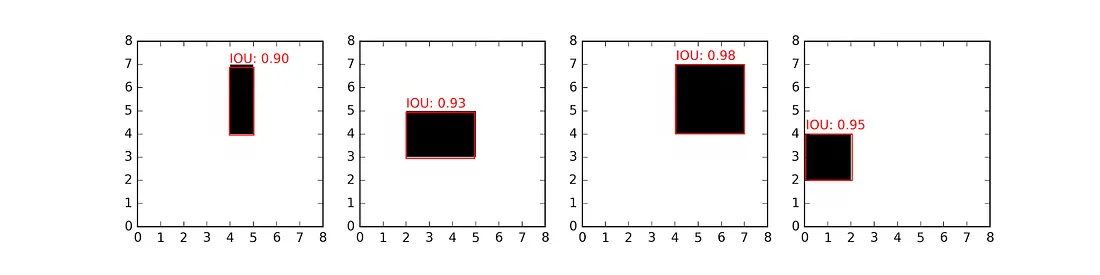

This NN when trained with 40k random images for 50 epochs (~1 minute training time) almost got perfect results with results shown above - average IOU was 0.96

IOU - This index is called Intersection Over Union and measures the overlap between the predicted and the real bounding box. It’s calculated by dividing the area of intersection (red in the image below) by the area of union (blue). The IOU is between 0 (no overlap) and 1 (perfect overlap). In the experiment above, I got an almost perfect IOU of 0.9 on average (on held-out test data).

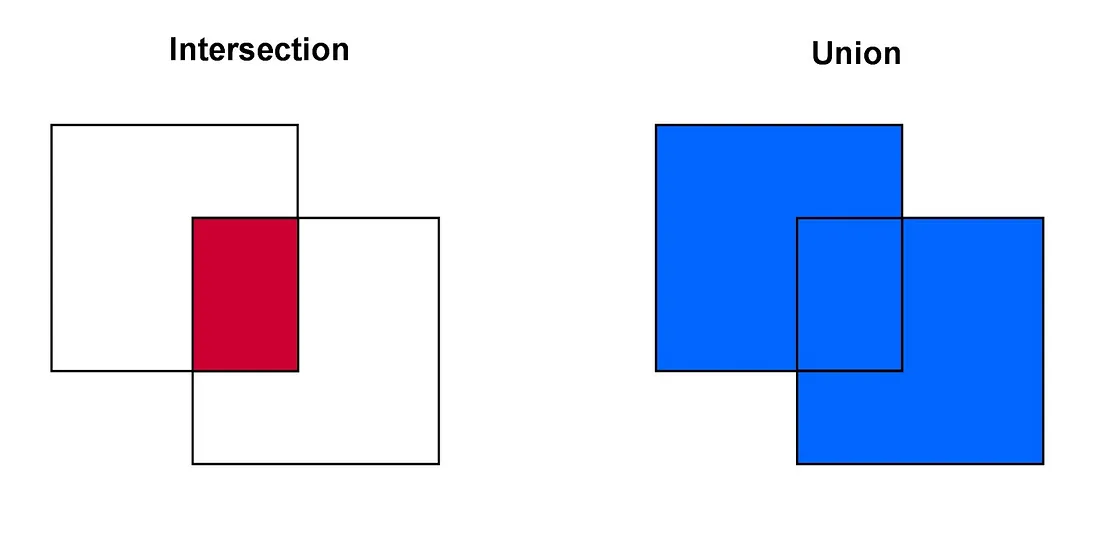


In [118]:
#train
# Flip bboxes during training.
# Note: The validation loss is always quite big here because we don't flip the bounding boxes for the validation data. 
import sys

def IOU(bbox1, bbox2):
    '''Calculate overlap between two bounding boxes [x, y, w, h] as the area of intersection over the area of unity'''
    x1, y1, w1, h1 = bbox1[0], bbox1[1], bbox1[2], bbox1[3]  # TODO: Check if its more performant if tensor elements are accessed directly below.
    x2, y2, w2, h2 = bbox2[0], bbox2[1], bbox2[2], bbox2[3]

    # compute x overlap and y overlap and multiply both overlap to get overlap/intersection area
    w_I = min(x1 + w1, x2 + w2) - max(x1, x2) # (left most rectangle x+ its width) - right most x - very simple formula to get x overlap
    h_I = min(y1 + h1, y2 + h2) - max(y1, y2)
    if w_I <= 0 or h_I <= 0:  # no overlap
        return 0
    I = w_I * h_I

    # rectangle union area = total area of both rectangles - 
    U = w1 * h1 + w2 * h2 - I

    return I / U

def distance(bbox1, bbox2):
    return np.sqrt(np.sum(np.square(bbox1[:2] - bbox2[:2]))) # looks - euclidean distance between lower left of both bounding boxes

num_epochs = 50
flipped_train_y = np.array(train_y) #clone the modified y array - flipped is because we flattened the original array earlier
flipped = np.zeros((len(flipped_train_y), num_epochs)) # create 40000 of 1 element array  (which is 80% of 50000 samples)
# print(flipped.shape)
# print(flipped[0])
ious_epoch = np.zeros((len(flipped_train_y), num_epochs)) #create 40000 array (to hold output IOU value) for each epoch of Num_epochs
dists_epoch = np.zeros((len(flipped_train_y), num_epochs)) #create 40000 array (to hold output distances value) for each epoch of Num_epochs
mses_epoch = np.zeros((len(flipped_train_y), num_epochs)) #create 40000 array (to hold output MSE value) for each epoch of Num_epochs

print(sys.version)


3.12.8 (tags/v3.12.8:2dc476b, Dec  3 2024, 19:30:04) [MSC v.1942 64 bit (AMD64)]


In [ ]:
# train without interchanging the bboxes


print(f'shape of train_X', train_X.shape)
print(f'shape of test_X', test_X.shape)
print(f'shape of flipped_train_y', flipped_train_y.shape)
print(f'shape of test_y', test_y.shape)
model.fit(train_X, flipped_train_y, epochs=num_epochs, validation_data=(test_X, test_y), verbose=2)

# perform prediction on training dataset itself
pred_y = model.predict(train_X)


plt.figure(figsize=(12, 3))
for i_subplot in range(1, 5):
    plt.subplot(1, 4, i_subplot)
    i = np.random.randint(len(test_X))
    plt.imshow(test_imgs[i].T, cmap='Greys', interpolation='none', origin='lower', extent=[0, img_size, 0, img_size])
    for pred_bbox, exp_bbox in zip(pred_y[i], train_bboxes[i]):
        plt.gca().add_patch(matplotlib.patches.Rectangle((pred_bbox[0], pred_bbox[1]), pred_bbox[2], pred_bbox[3], ec='r', fc='none')) # draw red predicted bounding box
        # TODO: Calculate max IOU with all expected bounding boxes.
#         plt.annotate('IOU: {:.2f}'.format(IOU(pred_bbox, exp_bbox)), (pred_bbox[0], pred_bbox[1]+pred_bbox[3]+0.4), color='r')




        

shape of train_X (40000, 64)
shape of test_X (10000, 64)
shape of flipped_train_y (40000, 4)
shape of test_y (10000, 4)
Epoch 0


ValueError: Exception encountered when calling Sequential.call().

[1mInvalid input shape for input Tensor("data:0", shape=(32, 64), dtype=float32). Expected shape (None, 28, 28, 1), but input has incompatible shape (32, 64)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(32, 64), dtype=float32)
  • training=True
  • mask=None

In [81]:
# original code that interchanges the bounding boxes

for epoch in range(num_epochs):
    print( 'Epoch', epoch)
    #train the model - for current epoch send the features (rectangle images) and expected output (expected bounding boxes)
    #validation_data: Data on which to evaluate the loss and any model metrics at the end of each epoch. The model will not be
    #  trained on this data. Thus, note the fact that the validation loss of data provided using validation_split or validation_data 
    # is not affected by regularization layers like noise and dropout. validation_data will override validation_split.

    model.fit(train_X, flipped_train_y, epochs=1, validation_data=(test_X, test_y), verbose=2)

    # perform prediction on training dataset itself
    pred_y = model.predict(train_X)


    for sample, (pred_bboxes, exp_bboxes) in enumerate(zip(pred_y, flipped_train_y)):
        # find out the bounding box predicted was for which of  the rectrangles in the image.
        pred_bboxes = pred_bboxes.reshape(num_objects, -1)
        exp_bboxes = exp_bboxes.reshape(num_objects, -1)

        ious = np.zeros((num_objects, num_objects))
        dists = np.zeros((num_objects, num_objects))
        mses = np.zeros((num_objects, num_objects))
        for i, exp_bbox in enumerate(exp_bboxes):
            for j, pred_bbox in enumerate(pred_bboxes): # find IOU value for all combinations of features (input rectangle) and predicted bounding boxes
                ious[i, j] = IOU(exp_bbox, pred_bbox)
                dists[i, j] = distance(exp_bbox, pred_bbox)
                mses[i, j] = np.mean(np.square(exp_bbox - pred_bbox))
                
        new_order = np.zeros(num_objects, dtype=int)
        
        for i in range(num_objects):
            # the output predeicted will have size of 4*num_objects (ie., number of rectangles) in the image
            # we have to match each 4 outputs to the correct rectangle it might be representaing. For this we use 
            # here we are changing the predicted output (bounding box) based on the IOU value to assign it to correct rectangle of input image.
            # self-note - NN gave a predicted bounding box but we are not sure which of the reactangles in the image is the predicted bounding box given for ?
            # Find pred and expected bbox with minimum mse and assign them to each other (i.e. switch the positions of the exp bboxes in y).
            ind_exp_bbox, ind_pred_bbox = np.unravel_index(mses.argmin(), mses.shape)
            ious_epoch[sample, epoch] += ious[ind_exp_bbox, ind_pred_bbox]
            dists_epoch[sample, epoch] += dists[ind_exp_bbox, ind_pred_bbox]
            mses_epoch[sample, epoch] += mses[ind_exp_bbox, ind_pred_bbox]
            mses[ind_exp_bbox] = 10000000#-1  # set mse of assigned bboxes to a large number, so they don't get assigned again
            mses[:, ind_pred_bbox] = 10000000#-1
            new_order[ind_pred_bbox] = ind_exp_bbox
        
        # Write flipped bboxes to training data. self-note - we found that NN is outputing bounding bozes in certain order and hence we are chaning the output to reflect same order
        flipped_train_y[sample] = exp_bboxes[new_order].flatten()
        
        flipped[sample, epoch] = 1. - np.mean(new_order == np.arange(num_objects, dtype=int))#np.array_equal(new_order, np.arange(num_objects, dtype=int))  # TODO: Change this to reflect the number of flips.
        ious_epoch[sample, epoch] /= num_objects
        dists_epoch[sample, epoch] /= num_objects
        mses_epoch[sample, epoch] /= num_objects
        
            
    print( 'Flipped {} % of all elements'.format(np.mean(flipped[:, epoch]) * 100.))
    print( 'Mean IOU: {}'.format(np.mean(ious_epoch[:, epoch])))
    print( 'Mean dist: {}'.format(np.mean(dists_epoch[:, epoch])))
    print( 'Mean mse: {}'.format(np.mean(mses_epoch[:, epoch])))
    

Epoch 0
1250/1250 - 5s - 4ms/step - loss: 0.8894 - val_loss: 0.5270
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
Flipped 0.0 % of all elements
Mean IOU: 0.0006124091330954554
Mean dist: 1.09018164201601
Mean mse: 0.5207164289139594
Epoch 1
1250/1250 - 3s - 3ms/step - loss: 0.7100 - val_loss: 0.3766
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
Flipped 0.0 % of all elements
Mean IOU: 0.0038176547466158275
Mean dist: 0.9018665891472769
Mean mse: 0.37258648389825866
Epoch 2
1250/1250 - 3s - 3ms/step - loss: 0.5825 - val_loss: 0.2790
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
Flipped 0.0 % of all elements
Mean IOU: 0.007946598798891352
Mean dist: 0.7596723944966761
Mean mse: 0.27668027026996317
Epoch 3
1250/1250 - 3s - 3ms/step - loss: 0.5015 - val_loss: 0.2180
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Flipped 0.0 % of all elements
Mean IOU: 0.01091220568696462
Mean dist: 0.6586074742010622
Mean mse: 0.21696862223902885
Epoch 4
1250/1250 - 3s - 3ms/step - loss: 0.4530 - val_loss: 0.1795
1250/1

(40000, 50)


Text(0, 0.5, 'Training sample')

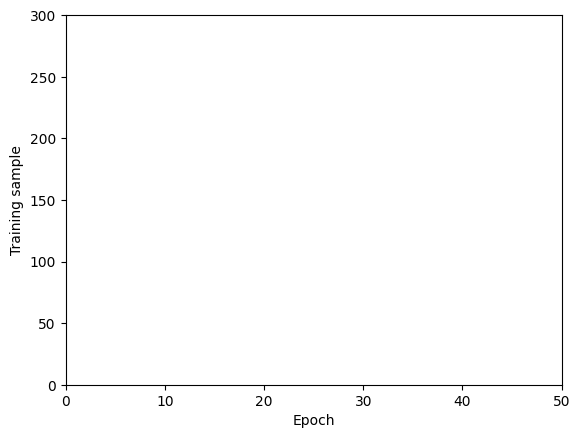

In [115]:
# Show flippings for a few training samples.
print(flipped.shape)
plt.pcolor(flipped[:300], cmap='Greys', vmax=1.)
plt.xlabel('Epoch')
plt.ylabel('Training sample')

(0.0, 1.0)

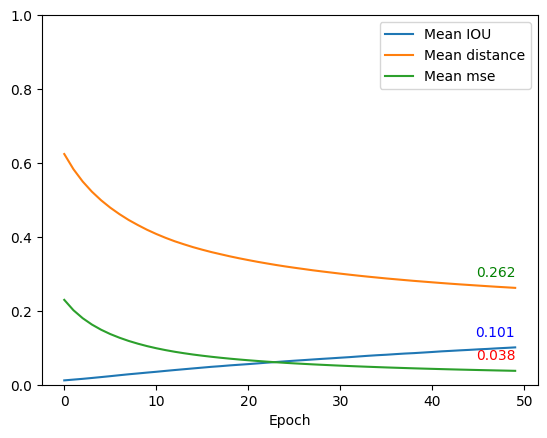

In [68]:
# Plot metrics on the training data. 
mean_ious_epoch = np.mean(ious_epoch, axis=0)
mean_dists_epoch = np.mean(dists_epoch, axis=0)
mean_mses_epoch = np.mean(mses_epoch, axis=0)
plt.plot(mean_ious_epoch, label='Mean IOU')  # between predicted and assigned true bboxes
plt.plot(mean_dists_epoch, label='Mean distance')  # relative to image size
plt.plot(mean_mses_epoch, label='Mean mse')
plt.annotate(np.round(np.max(mean_ious_epoch), 3), (len(mean_ious_epoch)-1, mean_ious_epoch[-1]+0.03), horizontalalignment='right', color='b')
plt.annotate(np.round(np.min(mean_dists_epoch), 3), (len(mean_dists_epoch)-1, mean_dists_epoch[-1]+0.03), horizontalalignment='right', color='g')
plt.annotate(np.round(np.min(mean_mses_epoch), 3), (len(mean_mses_epoch)-1, mean_mses_epoch[-1]+0.03), horizontalalignment='right', color='r')
plt.xlabel('Epoch')
plt.legend()
plt.ylim(0, 1)

# plt.savefig('plots/bw-three-rectangles-50k.png', dpi=300)

In [108]:
pred_y = model.predict(test_X)
pred_bboxes = pred_y * img_size
pred_bboxes = pred_bboxes.reshape(len(pred_bboxes), num_objects, -1)
pred_bboxes.shape

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


(10000, 2, 4)

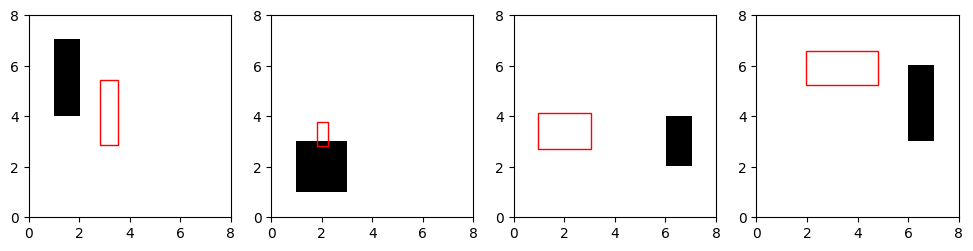

In [116]:
plt.figure(figsize=(12, 3))
for i_subplot in range(1, 5):
    plt.subplot(1, 4, i_subplot)
    i = np.random.randint(len(test_X))
    plt.imshow(test_imgs[i].T, cmap='Greys', interpolation='none', origin='lower', extent=[0, img_size, 0, img_size])
    for pred_bbox, exp_bbox in zip(pred_bboxes[i], test_bboxes[i]):
        plt.gca().add_patch(matplotlib.patches.Rectangle((pred_bbox[0], pred_bbox[1]), pred_bbox[2], pred_bbox[3], ec='r', fc='none')) # draw red predicted bounding box
        # TODO: Calculate max IOU with all expected bounding boxes.
#         plt.annotate('IOU: {:.2f}'.format(IOU(pred_bbox, exp_bbox)), (pred_bbox[0], pred_bbox[1]+pred_bbox[3]+0.4), color='r')